In [10]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib import container
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
import tabulate 

import IPython

In [12]:
%autoreload 2

from util import *

In [13]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load Data

In [14]:
# CPI: https://www.minneapolisfed.org/about-us/monetary-policy/inflation-calculator/consumer-price-index-1913-
cpi_map = {
    2013: 233,
    2014: 236.7,
    2015: 237,
    2016: 240,
    2017: 245.1,
    2018: 251.1,
    2019: 255.7,
    2020: 258.8,
    2021: 271,
    2022: 292.7,
    2023: 304.7,
    2024: 313.7,
    2025: 322.3
}

In [15]:
pain_cpt = {
    "facet_block": ["64490", "64493", "64491", "64492", "64495"],
    # "transforaminal_esi": ["64483", "64484"],
    # "interlaminar_caudal_esi": ["62320", "62321", "62322", "62323"],
    "esi": ["64483", "64484"],
    "esi_new": ["62320", "62321", "62322", "62323"],
    "deleted_esi": ["62310", "62311", "62312", "62313", "62314", "62315", "62316", "62317", "62318", "62319"],
    # "facet_rfa": ["64633", "64634", "64635", "64636"],
    # "si_joint_rfa": ["64628", "64629"],
    "rfa": ["64633", "64634", "64635", "64636", "64628", "64629"],
    "vertebral_augmentation": ["22510", "22511", "22512", "22513", "22514", "22515"],
}

pain_addons = ["64491", "64492", "64495", "64634", "64636", "64484", "64629", "22512", "22515"]

cpt_map = {}

for category, codes in pain_cpt.items():
    for code in codes:
        if code not in pain_addons:
            cpt_map[int(code)] = category
            cpt_map[code] = category

In [16]:
for name in pain_cpt:
    print(name)
    print(", ".join([code for code in pain_cpt[name] if code not in pain_addons]))

facet_block
64490, 64493
esi
64483
esi_new
62320, 62321, 62322, 62323
deleted_esi
62310, 62311, 62312, 62313, 62314, 62315, 62316, 62317, 62318, 62319
rfa
64633, 64635, 64628
vertebral_augmentation
22510, 22511, 22513, 22514


In [17]:
current_dir = os.getcwd()

In [18]:
surg_data = pd.read_csv(os.path.join(current_dir, "processed-data", "surg_pain_cpt_processed.csv"))
nonsurg_data = pd.read_csv(os.path.join(current_dir, "processed-data", "nonsurg_pain_cpt_processed.csv"))

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_25473/1329423748.py:2: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  nonsurg_data = pd.read_csv(os.path.join(current_dir, "processed-data", "nonsurg_pain_cpt_processed.csv"))


In [19]:
surg_data['Rndrng_Prvdr_Type'].unique()

array(['Neurosurgery', 'Orthopedic Surgery'], dtype=object)

# Set Up Dataframes

In [20]:
for df in [surg_data, nonsurg_data]:
    df['CPI'] = df['year'].map(cpi_map).fillna(0)
    
    # Adjusted amounts
    df['Avg_Mdcr_Stdzd_Amt_adj'] = df['Avg_Mdcr_Stdzd_Amt'] / df['CPI'] * cpi_map[2023]
    df['Avg_Mdcr_Pymt_Amt_adj'] = df['Avg_Mdcr_Pymt_Amt'] / df['CPI'] * cpi_map[2023]

    # Raw amounts summed over services per provider
    df['Tot_Srvcs_Spend'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt'] 
    df['Tot_Pymt'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt'] 

    # Raw amounts summed over services per provider, adjusted
    df['Tot_Srvcs_Spend_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt_adj'] 
    df['Tot_Pymt_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt_adj'] 

# Select only necessary comlumns
surg_data = surg_data[[
    "HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", 
    "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj",
    "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"
]]
nonsurg_data = nonsurg_data[[
    "HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", 
    "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj",
    "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"
]]

for data in [surg_data, nonsurg_data]:
    data['procedure'] = data['HCPCS_Cd'].map(cpt_map)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_25473/16570732.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['procedure'] = data['HCPCS_Cd'].map(cpt_map)


In [21]:
groupby_key = 'procedure'
specialty_name = ["Surgical", "Nonsurgical"]

# Group by procedure and year, and summarize
util_2023_2013_adj_surg = (
    surg_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
    )
)

util_2023_2013_adj_nonsurg = (
    nonsurg_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
)

# Get CIs for Avg_Mdcr_Stdzd_Amt
ci_surg = bootstrap_agg_price_ci(surg_data, groupby_key)
util_2023_2013_adj_surg = util_2023_2013_adj_surg.merge(ci_surg, on=[groupby_key, 'year'], how='left')

ci_nonsurg = bootstrap_agg_price_ci(nonsurg_data, groupby_key)
util_2023_2013_adj_nonsurg = util_2023_2013_adj_nonsurg.merge(ci_nonsurg, on=[groupby_key, 'year'], how='left')

In [22]:
# util_2023_2013_adj_surg = util_2023_2013_adj_surg[util_2023_2013_adj_surg['year'] <= 2021].reset_index(drop=True)
# util_2023_2013_adj_nonsurg = util_2023_2013_adj_nonsurg[util_2023_2013_adj_nonsurg['year'] <= 2021].reset_index(drop=True)

In [23]:
for df in [util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]:
    df['Agg_Price_per_service_adj'] = df['Sum_Spend_adj'] / df['Sum_Utilization']

# Utilization

In [24]:
util_2023_2013_adj_surg['Sum_Utilization'].sum(), util_2023_2013_adj_nonsurg['Sum_Utilization'].sum()

(1004145.0, 11621462.0)

In [25]:
util_2023_2013_adj_surg.groupby('procedure')['Sum_Utilization'].sum()

procedure
deleted_esi               169779.0
esi                       339927.0
esi_new                   200284.0
facet_block               186418.0
rfa                        27562.0
vertebral_augmentation     80175.0
Name: Sum_Utilization, dtype: float64

In [26]:
util_2023_2013_adj_nonsurg.groupby('procedure')['Sum_Utilization'].sum()

procedure
deleted_esi               1581836.0
esi                       3177298.0
esi_new                   2384894.0
facet_block               2958538.0
rfa                       1484254.0
vertebral_augmentation      34642.0
Name: Sum_Utilization, dtype: float64

In [27]:
5562192.0/540211.0, 2958538.0/186418.0, 1484254.0/27562.0

(10.296332359022678, 15.870452424122135, 53.85146215804368)

In [28]:
80175.0/34642.0

2.314387160094683

In [29]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Utilization',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [30]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Surgical | unweighted AAGR: -3.758 | weighted AAGR: -4.152

    procedure                   AAGR_%
--  ----------------------  ----------
 0  deleted_esi              -0.900904
 1  esi                      -2.68024
 2  esi_new                 -10.2538
 3  facet_block              -3.9215
 4  rfa                       2.7278
 5  vertebral_augmentation   -7.51997

Nonsurgical | unweighted AAGR: 0.123 | weighted AAGR: -0.578

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi             -0.385022
 1  esi                     -0.809607
 2  esi_new                 -4.3316
 3  facet_block              1.06279
 4  rfa                      5.55416
 5  vertebral_augmentation  -0.351377



In [31]:
stats.ttest_rel(aagrs['Surgical'][0]['AAGR_%'], aagrs['Nonsurgical'][0]['AAGR_%'])

TtestResult(statistic=-3.7193502555090796, pvalue=0.01372133624266836, df=5)

In [32]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    cagrs[specialty_name[i]] = compute_cagr(
        df,
        col='Sum_Utilization',
        groupby_key='procedure',
        years=[2013, 2023]
    )

In [33]:
for specialty, cagr in cagrs.items():
    print(specialty)
    print(tabulate.tabulate(cagr, headers=cagr.columns))
    print()

Surgical
    procedure                 CAGR_pct    effective_start_year    effective_end_year
--  ----------------------  ----------  ----------------------  --------------------
 0  deleted_esi               -3.01106                    2013                  2016
 1  esi                       -2.94471                    2013                  2023
 2  esi_new                  -10.6304                     2017                  2023
 3  facet_block               -4.12676                    2013                  2023
 4  rfa                        2.16725                    2013                  2023
 5  vertebral_augmentation    -8.00547                    2015                  2023

Nonsurgical
    procedure                 CAGR_pct    effective_start_year    effective_end_year
--  ----------------------  ----------  ----------------------  --------------------
 0  deleted_esi              -1.46691                     2013                  2016
 1  esi                      -1.14718      

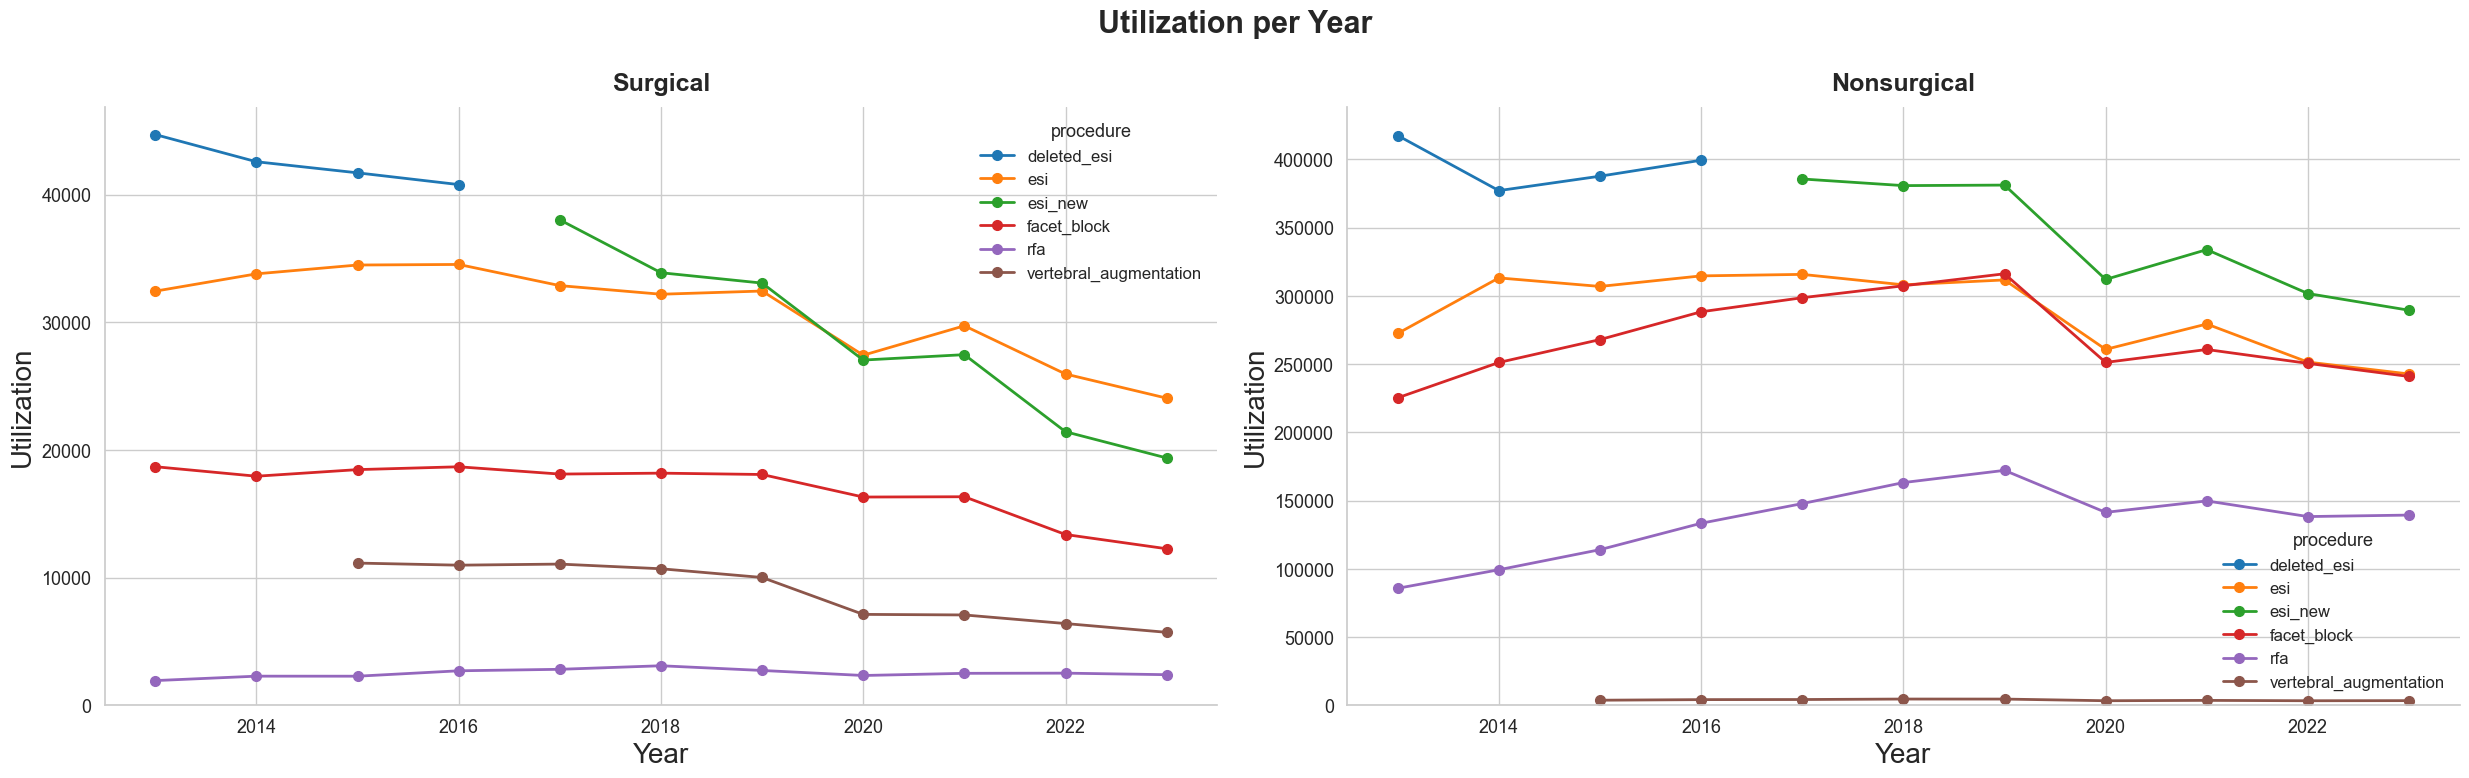

In [34]:
plot_by_specialty(
    [util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg],
    specialty_name,
    y_col='Sum_Utilization',
    y_label='Utilization',
    figsize=(25, 8),
    title="Utilization per Year"
)

# Average Standardized Payment

In [35]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Avg_Price_per_service_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [36]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Surgical | unweighted AAGR: 1.455 | weighted AAGR: 3.288

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi              3.34494
 1  esi                     -0.529778
 2  esi_new                 -1.90282
 3  facet_block              1.45566
 4  rfa                      1.89208
 5  vertebral_augmentation   4.46813

Nonsurgical | unweighted AAGR: 0.414 | weighted AAGR: 2.682

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi              3.03726
 1  esi                     -1.05022
 2  esi_new                 -2.86537
 3  facet_block              0.124281
 4  rfa                     -0.617386
 5  vertebral_augmentation   3.85601



In [37]:
stats.ttest_rel(aagrs['Surgical'][0]['AAGR_%'], aagrs['Nonsurgical'][0]['AAGR_%'])

TtestResult(statistic=3.1666695203332624, pvalue=0.02490786337970255, df=5)

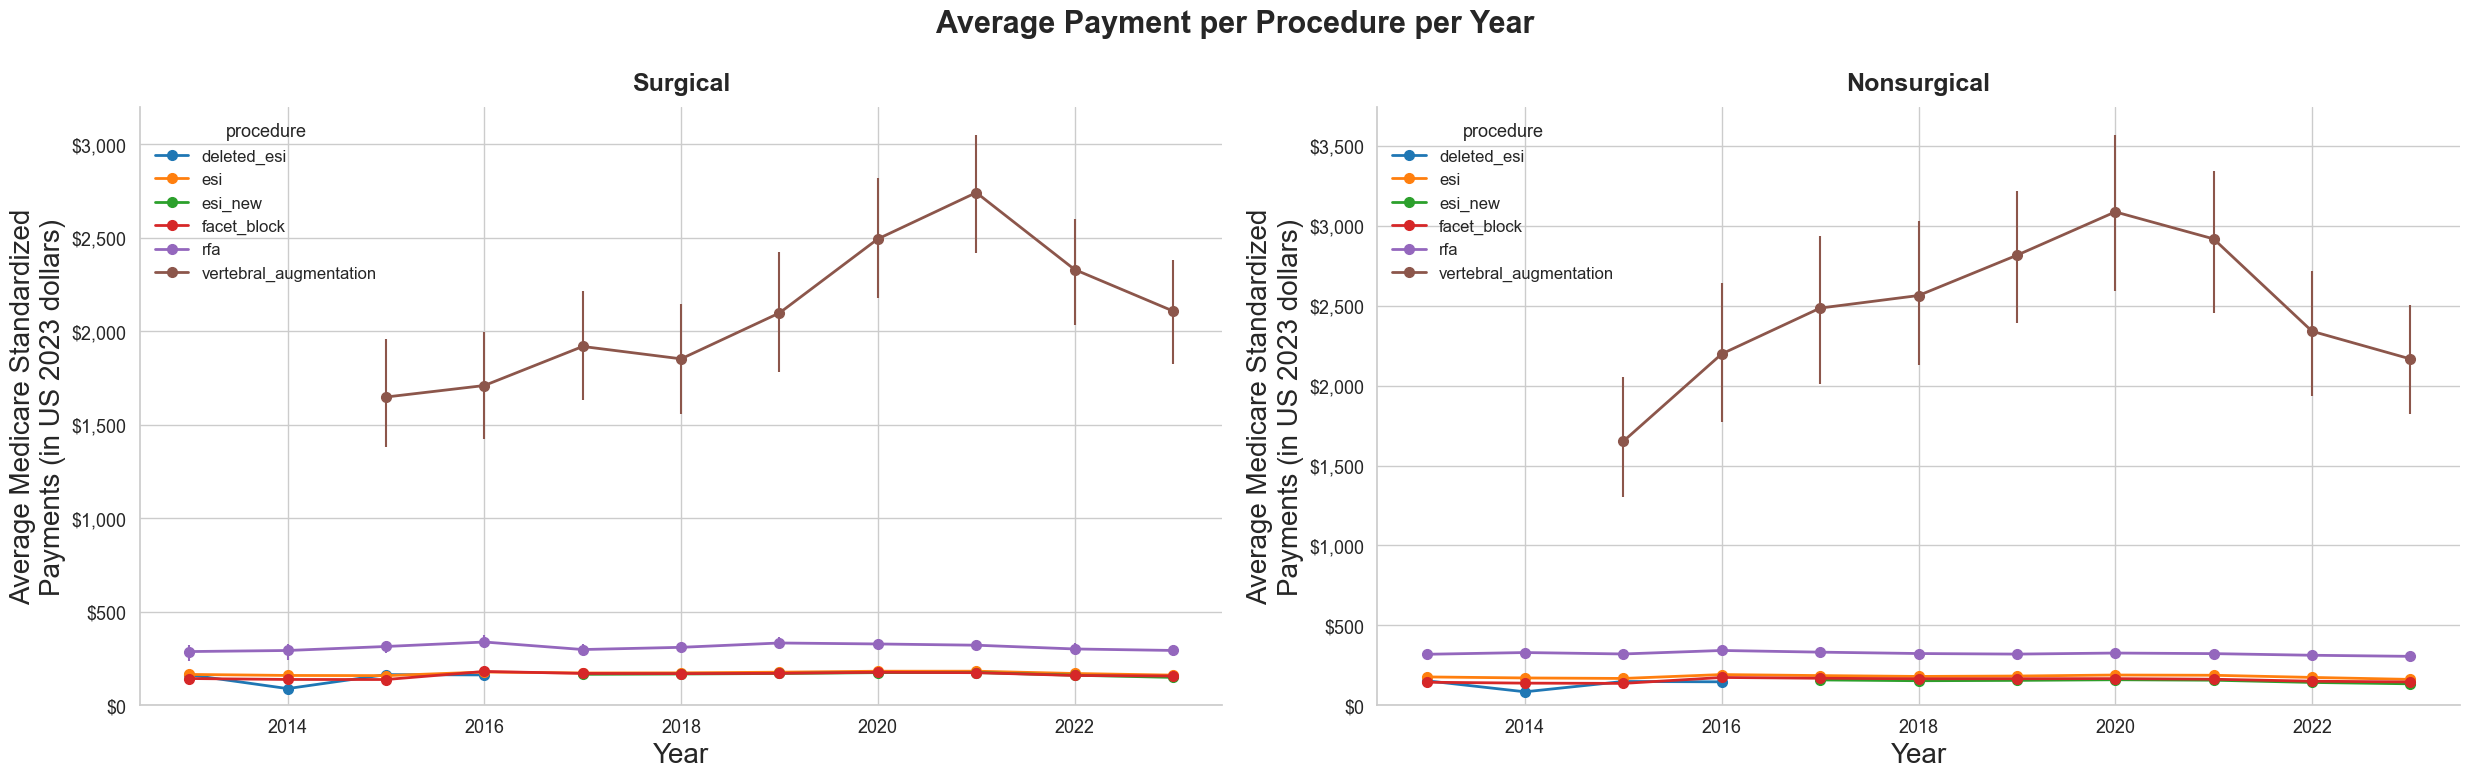

In [38]:
# Usage
plot_by_specialty_with_ci(
    [util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg],
    specialty_name,
    y_col='Agg_Price_per_service_adj',
    ci_lower_col='CI_lower_agg_price_adj',
    ci_upper_col='CI_upper_agg_price_adj',
    y_label="Average Medicare Standardized\nPayments (in US 2023 dollars)",
    title_prefix="Average Medicare Standardized Payment by Procedure Type",
    title="Average Payment per Procedure per Year"
)

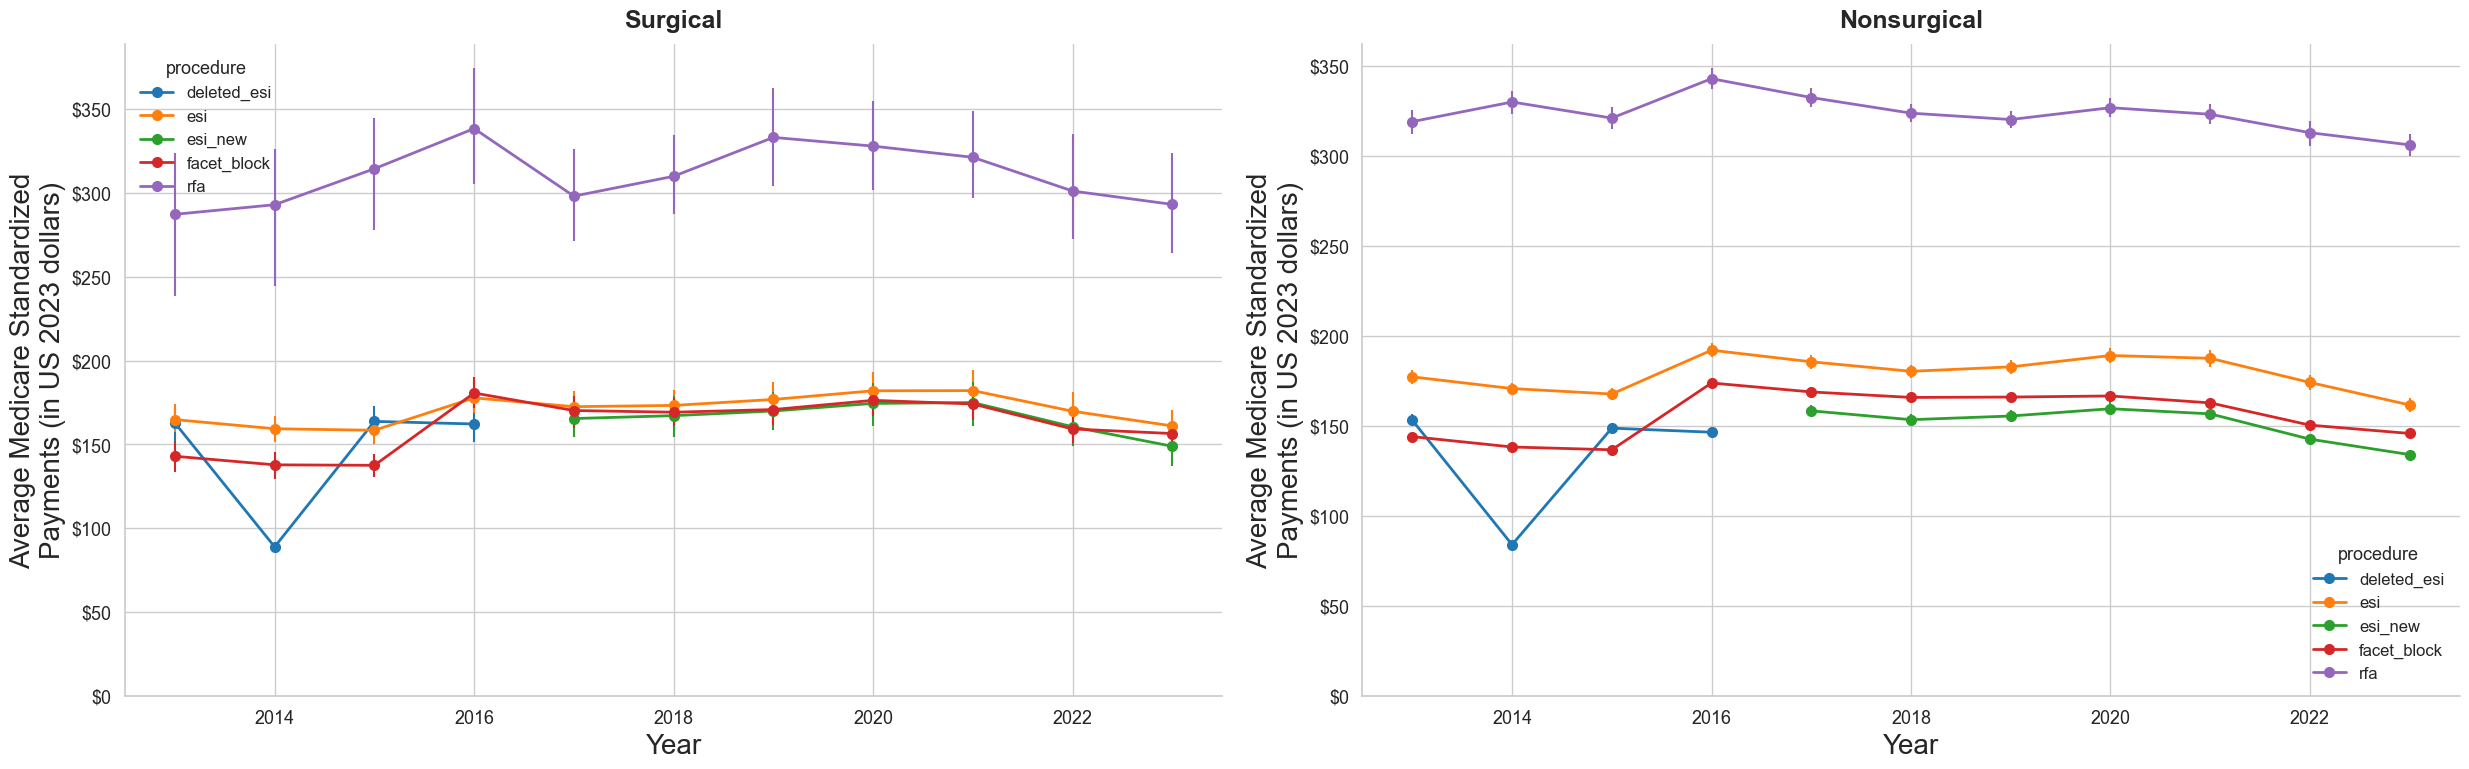

In [39]:
# Usage
plot_by_specialty_with_ci(
    [util_2023_2013_adj_surg[util_2023_2013_adj_surg['procedure'] != "vertebral_augmentation"], util_2023_2013_adj_nonsurg[util_2023_2013_adj_nonsurg['procedure'] != "vertebral_augmentation"]],
    specialty_name,
    y_col='Agg_Price_per_service_adj',
    ci_lower_col='CI_lower_agg_price_adj',
    ci_upper_col='CI_upper_agg_price_adj',
    y_label="Average Medicare Standardized\nPayments (in US 2023 dollars)",
    title_prefix="Average Medicare Standardized Payment by Procedure Type",
)

# Total Payment

In [40]:
util_2023_2013_adj_surg['Sum_Pymt_adj'].sum(), util_2023_2013_adj_nonsurg['Sum_Pymt_adj'].sum()

(316527493.984913, 2176047189.2957935)

In [41]:
surg_total_payment_2013 = util_2023_2013_adj_surg[util_2023_2013_adj_surg['year'] == 2013]['Sum_Pymt_adj'].sum()
surg_total_payment_2023 = util_2023_2013_adj_surg[util_2023_2013_adj_surg['year'] == 2023]['Sum_Pymt_adj'].sum()

(surg_total_payment_2023 - surg_total_payment_2013) / surg_total_payment_2013 * 100

27.46217562594356

In [42]:
nonsurg_total_payment_2013 = util_2023_2013_adj_nonsurg[util_2023_2013_adj_nonsurg['year'] == 2013]['Sum_Pymt_adj'].sum()
nonsurg_total_payment_2023 = util_2023_2013_adj_nonsurg[util_2023_2013_adj_nonsurg['year'] == 2023]['Sum_Pymt_adj'].sum()

(nonsurg_total_payment_2023 - nonsurg_total_payment_2013) / nonsurg_total_payment_2013 * 100

-11.417037662683043

In [43]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [44]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Surgical | unweighted AAGR: -3.26 | weighted AAGR: -3.674

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi               2.65565
 1  esi                      -3.5531
 2  esi_new                 -10.9634
 3  facet_block              -5.14264
 4  rfa                       1.31777
 5  vertebral_augmentation   -3.87695

Nonsurgical | unweighted AAGR: 0.375 | weighted AAGR: -0.442

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi              3.1419
 1  esi                     -2.63105
 2  esi_new                 -6.45463
 3  facet_block             -0.900118
 4  rfa                      4.48371
 5  vertebral_augmentation   4.61315



In [45]:
stats.ttest_rel(aagrs['Surgical'][0]['AAGR_%'], aagrs['Nonsurgical'][0]['AAGR_%'])

TtestResult(statistic=-3.065666586268131, pvalue=0.027921199279384145, df=5)

In [46]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    cagrs[specialty_name[i]] = compute_cagr(
        df,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
        years=[2013, 2023]
    )

In [47]:
for specialty, cagr in cagrs.items():
    print(specialty)
    print(tabulate.tabulate(cagr, headers=cagr.columns))
    print()

Surgical
    procedure                 CAGR_pct    effective_start_year    effective_end_year
--  ----------------------  ----------  ----------------------  --------------------
 0  deleted_esi               -3.20443                    2013                  2016
 1  esi                       -3.95071                    2013                  2023
 2  esi_new                  -11.6651                     2017                  2023
 3  facet_block               -5.50427                    2013                  2023
 4  rfa                        0.64865                    2013                  2023
 5  vertebral_augmentation    -4.81803                    2015                  2023

Nonsurgical
    procedure                 CAGR_pct    effective_start_year    effective_end_year
--  ----------------------  ----------  ----------------------  --------------------
 0  deleted_esi               -2.59212                    2013                  2016
 1  esi                       -3.03669     

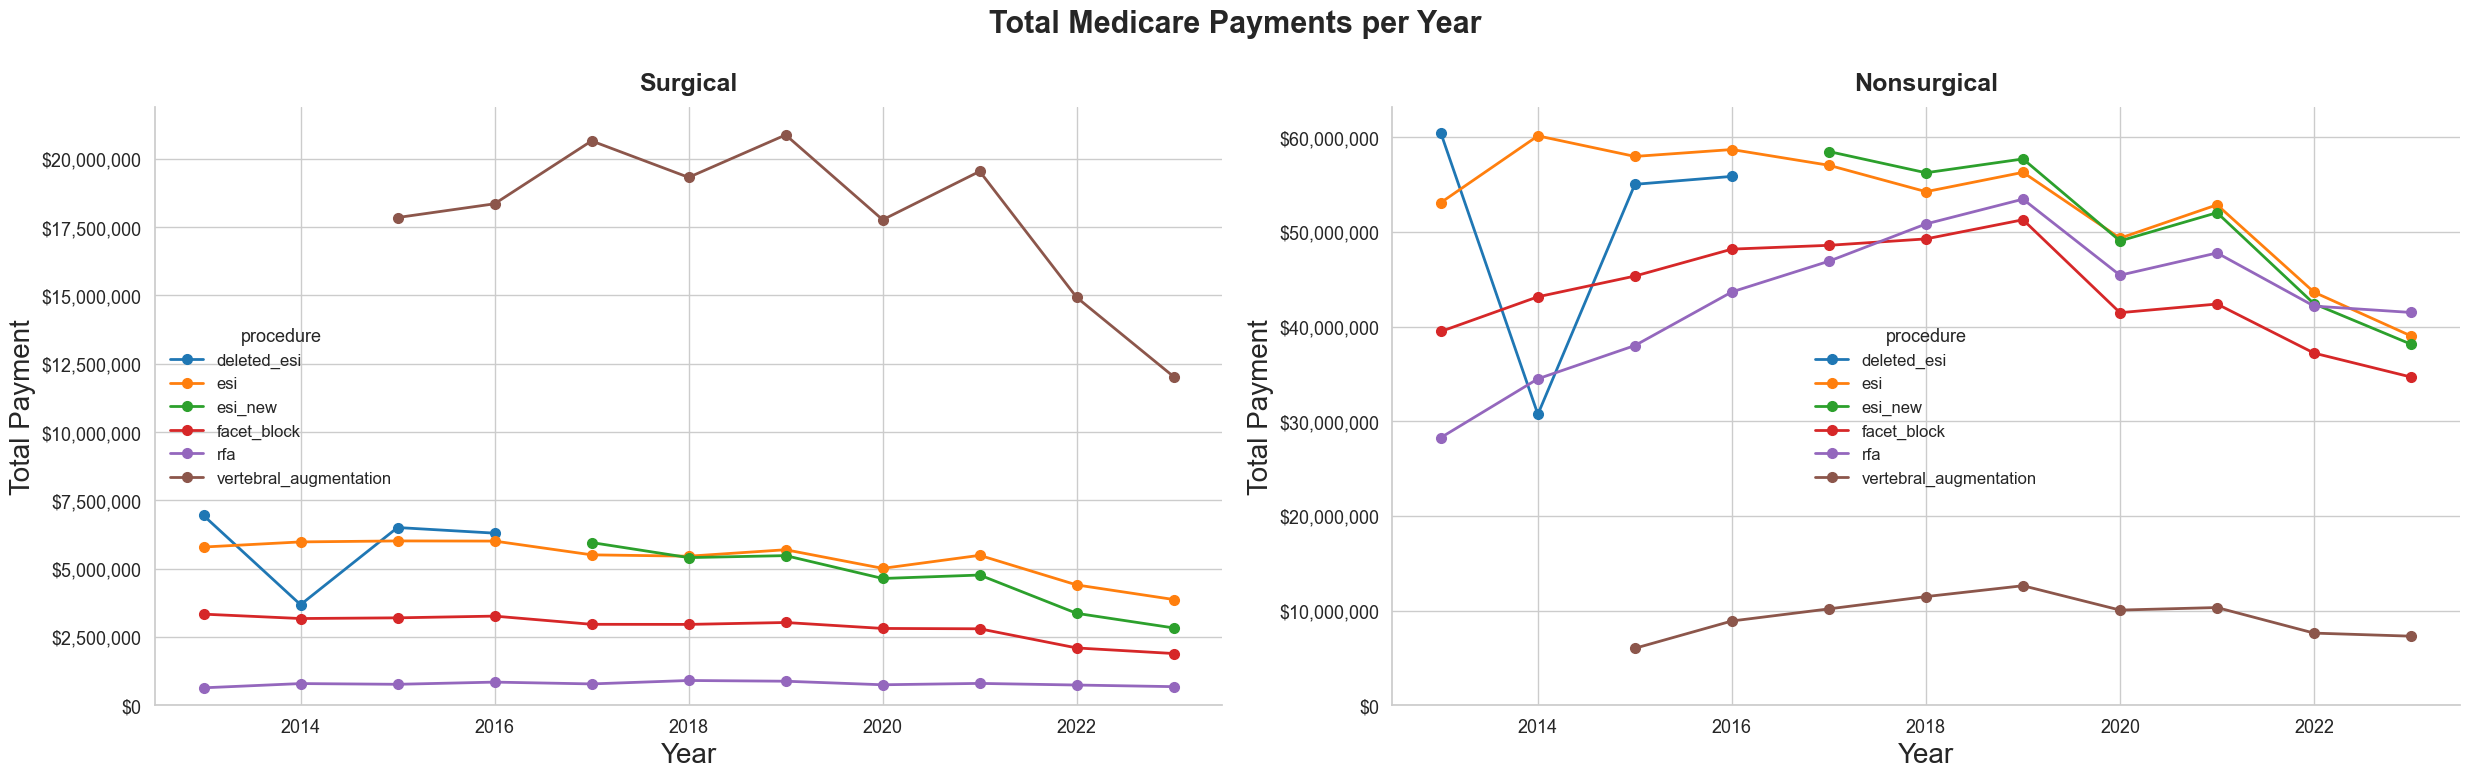

In [48]:
plot_by_specialty(
    [util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg],
    specialty_name,
    y_col='Sum_Pymt_adj',
    y_label='Total Payment',
    figsize=(25, 8),
    format_as_dollar=True,
    title="Total Medicare Payments per Year"
)

# Total Payment Growth Rate

In [49]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [50]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Surgical | unweighted AAGR: -3.26 | weighted AAGR: -3.674

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi               2.65565
 1  esi                      -3.5531
 2  esi_new                 -10.9634
 3  facet_block              -5.14264
 4  rfa                       1.31777
 5  vertebral_augmentation   -3.87695

Nonsurgical | unweighted AAGR: 0.375 | weighted AAGR: -0.442

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi              3.1419
 1  esi                     -2.63105
 2  esi_new                 -6.45463
 3  facet_block             -0.900118
 4  rfa                      4.48371
 5  vertebral_augmentation   4.61315



In [51]:
stats.ttest_rel(aagrs['Surgical'][0]['AAGR_%'], aagrs['Nonsurgical'][0]['AAGR_%'])

TtestResult(statistic=-3.065666586268131, pvalue=0.027921199279384145, df=5)

# Linear Regression by Change $ in Total Payment

In [133]:
# Usage
aagr_df_surg, aagr_df_nonsurg = compute_annual_change(
    [util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg],
    specialty_name,
    col='Sum_Pymt_adj',
    change_col_name='sum_pymt_change',
    start_year=2013,
    end_year=2023
)

In [134]:
x_variables = ['Sum_Utilization', 'Avg_Price_per_service_adj']

In [135]:
surg_data_for_regression = aagr_df_surg[['procedure', 'year', 'sum_pymt_change'] + x_variables]
surg_data_for_regression['specialty'] = 1

nonsurg_data_for_regression = aagr_df_nonsurg[['procedure', 'year', 'sum_pymt_change'] + x_variables]
nonsurg_data_for_regression['specialty'] = 0

all_regression_data = pd.concat([surg_data_for_regression, nonsurg_data_for_regression]).reset_index(drop=True).fillna(0)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90747/2204889466.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  surg_data_for_regression['specialty'] = 1
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90747/2204889466.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonsurg_data_for_regression['specialty'] = 0


In [136]:
X = all_regression_data.drop(columns=['sum_pymt_change', 'procedure']).dropna(subset=x_variables).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_pymt_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_pymt_change   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     3.373
Date:                Sat, 09 May 2026   Prob (F-statistic):             0.0111
Time:                        11:47:21   Log-Likelihood:                -2887.7
No. Observations:                 168   AIC:                             5785.
Df Residuals:                     163   BIC:                             5801.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

# Linear Regression by Change in Utilization

In [69]:
# Usage
aagr_df_surg, aagr_df_nonsurg = compute_annual_change(
    [util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg],
    specialty_name,
    col='Sum_Utilization',
    change_col_name='sum_util_change',
    start_year=2013,
    end_year=2016
)

In [70]:
surg_data_for_regression = aagr_df_surg[['procedure', 'year', 'Avg_Price_per_service_adj', 'sum_util_change']]
surg_data_for_regression['specialty'] = 0

nonsurg_data_for_regression = aagr_df_nonsurg[['procedure', 'year', 'Avg_Price_per_service_adj', 'sum_util_change']]
nonsurg_data_for_regression['specialty'] = 1

all_regression_data = pd.concat([surg_data_for_regression, nonsurg_data_for_regression]).reset_index(drop=True).fillna(0)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90747/3324088510.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90747/3324088510.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [71]:
X = all_regression_data.drop(columns=['sum_util_change', 'procedure']).dropna(subset=['Avg_Price_per_service_adj']).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_util_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_util_change   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.233
Date:                Sat, 09 May 2026   Prob (F-statistic):              0.307
Time:                        10:04:00   Log-Likelihood:                -595.55
No. Observations:                  56   AIC:                             1199.
Df Residuals:                      52   BIC:                             1207.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 